In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, cross_val_score

print("pandas version:", pd.__version__)            # version used: 2.2.3
print("seaborn version:", sns.__version__)            # version used: 0.13.2
print("matplotlib version:", plt.matplotlib.__version__)       # version used: 3.9.2
print("sklearn version:", sklearn.__version__)       # version used: 1.5.2

pandas version: 2.2.3
seaborn version: 0.13.2
matplotlib version: 3.9.2
sklearn version: 1.5.2


In [58]:
file_path = "C:/Users/wimva/OneDrive/Documenten/Semestersiete/Groep/Borne structured data.xlsx"
sheet_name = "Individual treatments"

data = pd.read_excel(file_path, sheet_name=sheet_name)
initial_row_count = len(data)
print(f"Initial number of rows: {initial_row_count}")

filtered_data = data[data['Diagnose'] != 'Groei achterstand']
after_diagnosis_filter_count = len(filtered_data)
print(f"Rows after filtering out 'Groei achterstand': {after_diagnosis_filter_count} (Removed: {initial_row_count - after_diagnosis_filter_count})")

filtered_data.loc[:, 'Datum'] = pd.to_datetime(filtered_data['Datum'], errors='coerce')
filtered_data = filtered_data.dropna(subset=['Datum'])
after_date_filter_count = len(filtered_data)
print(f"Rows after dropping invalid dates: {after_date_filter_count} (Removed: {after_diagnosis_filter_count - after_date_filter_count})")

filtered_data = filtered_data.sort_values(by=['Lev.nr', 'Datum'])

unique_treatments = filtered_data.drop_duplicates(subset='Lev.nr', keep='first')
after_deduplication_count = len(unique_treatments)
print(f"Rows after dropping duplicate treatments for the same calf: {after_deduplication_count} (Removed: {after_date_filter_count - after_deduplication_count})")

treatment_counts = unique_treatments.groupby('Datum').size().reset_index(name='Total Treatments')

treatment_counts['Datum'] = treatment_counts['Datum'].dt.strftime('%d/%m/%Y')

treatment_counts.rename(columns={'Datum': 'Date'}, inplace=True)

print(treatment_counts)

Initial number of rows: 4983
Rows after filtering out 'Groei achterstand': 4734 (Removed: 249)
Rows after dropping invalid dates: 4734 (Removed: 0)
Rows after dropping duplicate treatments for the same calf: 1552 (Removed: 3182)
           Date  Total Treatments
0    12/10/2021                 1
1    24/11/2021                 1
2    15/12/2021                 1
3    16/12/2021                 3
4    17/12/2021                 5
..          ...               ...
393  04/10/2024                 6
394  06/10/2024                 2
395  04/11/2024                 5
396  07/11/2024                 1
397  04/12/2024                10

[398 rows x 2 columns]


In [59]:
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

weather_files = [
    "C:/Users/wimva/Downloads/06290099999 2021-05-18 to 2022-05-01.xlsx",
    "C:/Users/wimva/Downloads/06290099999 2024-01-10 to 2025-01-06.xlsx",
    "C:/Users/wimva/Downloads/06290099999 2022-05-01 to 2023-01-14.xlsx",
    "C:/Users/wimva/Downloads/06290099999 2023-01-14 to 2024-01-10.xlsx",
    "C:/Users/wimva/Downloads/06290099999 2021-01-01 to 2021-05-18.xlsx"
]

weather_data = pd.concat([pd.read_excel(file) for file in weather_files], ignore_index=True)

weather_data['datetime'] = pd.to_datetime(weather_data['datetime'])

weather_data = weather_data.sort_values(by='datetime')

weather_data.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
1333,6290099999,2021-01-01,4.1,-1.6,1.6,2.3,-4.4,-0.1,1.2,96.8,...,2.3,1.0,NaN,2021-01-01T08:42:04,2021-01-01T16:30:30,0.58,Overcast,Cloudy skies throughout the day.,cloudy,"remote,06290099999"
1334,6290099999,2021-01-02,3.7,2.7,3.1,3.2,-1.0,1.0,2.6,96.8,...,1.4,1.0,NaN,2021-01-02T08:41:55,2021-01-02T16:31:37,0.62,"Rain, Overcast",Cloudy skies throughout the day with rain in t...,rain,"remote,06290099999"
1335,6290099999,2021-01-03,3.6,2.4,3.0,2.9,-2.5,-0.6,1.2,88.5,...,2.4,1.0,NaN,2021-01-03T08:41:41,2021-01-03T16:32:46,0.65,"Rain, Overcast",Cloudy skies throughout the day with late afte...,rain,"remote,06290099999"
1336,6290099999,2021-01-04,3.2,1.7,2.6,-1.0,-3.1,-2.0,1.2,90.5,...,0.9,1.0,NaN,2021-01-04T08:41:25,2021-01-04T16:33:59,0.69,"Snow, Rain, Overcast",Cloudy skies throughout the day with rain or s...,rain,"remote,06290099999"
1337,6290099999,2021-01-05,3.4,1.7,2.5,-0.2,-2.9,-1.5,1.3,91.6,...,1.1,1.0,NaN,2021-01-05T08:41:05,2021-01-05T16:35:13,0.72,"Rain, Overcast",Cloudy skies throughout the day with late afte...,rain,"remote,06290099999"


In [60]:
weather_data = weather_data[['datetime', 'tempmax', 'tempmin', 'humidity', 'precip', 'preciptype', 'windgust', 'windspeed']]

weather_data = weather_data.dropna(subset=['datetime'])

In [61]:
treatment_counts['Date'] = pd.to_datetime(treatment_counts['Date'], format='%d/%m/%Y')

def parse_preciptype(preciptype):
    if pd.isna(preciptype):
        return 0, 0
    preciptype = preciptype.lower()
    rain = 1 if 'rain' in preciptype else 0
    snow = 1 if 'snow' in preciptype else 0
    return rain, snow

def get_weather_for_last_7_days(date, weather_data):
    weather_features = {}
    
    for i in range(1, 8):
        target_date = date - pd.Timedelta(days=i)
        
        weather_on_day = weather_data[weather_data['datetime'] <= target_date].iloc[-1]
        
        rain, snow = parse_preciptype(weather_on_day['preciptype'])
        
        weather_features[f'tempmax_{i}_days_ago'] = weather_on_day['tempmax']
        weather_features[f'tempmin_{i}_days_ago'] = weather_on_day['tempmin']
        weather_features[f'humidity_{i}_days_ago'] = weather_on_day['humidity']
        weather_features[f'precip_{i}_days_ago'] = weather_on_day['precip']
        weather_features[f'rain_{i}_days_ago'] = rain
        weather_features[f'snow_{i}_days_ago'] = snow
        weather_features[f'windgust_{i}_days_ago'] = weather_on_day['windgust']
        weather_features[f'windspeed_{i}_days_ago'] = weather_on_day['windspeed']
    
    return weather_features

weather_features_list = treatment_counts['Date'].apply(lambda x: get_weather_for_last_7_days(x, weather_data))

weather_features_df = pd.DataFrame(weather_features_list.tolist())

treatment_counts_with_weather = pd.concat([treatment_counts, weather_features_df], axis=1)

treatment_counts_with_weather.head()

,Date,Total Treatments,tempmax_1_days_ago,tempmin_1_days_ago,humidity_1_days_ago,precip_1_days_ago,rain_1_days_ago,snow_1_days_ago,windgust_1_days_ago,windspeed_1_days_ago,...,windgust_6_days_ago,windspeed_6_days_ago,tempmax_7_days_ago,tempmin_7_days_ago,humidity_7_days_ago,precip_7_days_ago,rain_7_days_ago,snow_7_days_ago,windgust_7_days_ago,windspeed_7_days_ago
0,2021-10-12,1,15.9,7.9,87.4,1.0,1,0,32.4,18.0,...,47.2,25.2,17.9,8.9,81.9,2.7,1,0,39.6,25.2
1,2021-11-24,1,9.7,-0.9,97.2,1.0,1,0,15.5,7.2,...,39.6,25.2,10.2,4.4,94.2,0.4,1,0,32.4,18.0
2,2021-12-15,1,9.2,7.5,93.4,1.4,1,0,24.5,18.0,...,25.2,18.0,6.7,2.7,82.9,2.7,1,0,46.8,28.8
3,2021-12-16,3,10.2,8.9,94.5,0.5,1,0,28.8,18.0,...,25.2,14.4,4.4,0.2,90.1,0.2,1,0,25.2,18.0
4,2021-12-17,5,8.9,7.2,99.2,0.0,0,0,21.6,14.4,...,27.0,13.7,4.7,-3.9,87.7,0.0,0,0,25.2,14.4


In [62]:
snow_columns = [col for col in treatment_counts_with_weather.columns if col.startswith('snow_')]
rows_with_snow = (treatment_counts_with_weather[snow_columns] > 0).any(axis=1).sum()

print(f"Number of rows with at least one non-zero snow value: {rows_with_snow}")

Number of rows with at least one non-zero snow value: 77


In [63]:
rain_columns = [col for col in treatment_counts_with_weather.columns if col.startswith('rain_')]
snow_columns = [col for col in treatment_counts_with_weather.columns if col.startswith('snow_')]

rows_with_rain_and_snow = 0

for rain_col, snow_col in zip(rain_columns, snow_columns):
    rows_with_rain_and_snow += ((treatment_counts_with_weather[rain_col] == 1) & 
                                (treatment_counts_with_weather[snow_col] == 1)).sum()

print(f"Number of rows with both rain and snow equal to 1: {rows_with_rain_and_snow}")

Number of rows with both rain and snow equal to 1: 138


In [64]:
total_nan_values = treatment_counts_with_weather.isna().sum().sum()

print(f"Total number of NaN values in the DataFrame: {total_nan_values}")

Total number of NaN values in the DataFrame: 0


In [65]:
treatment_counts_with_weather_cleaned = treatment_counts_with_weather.drop(columns=['Date'])

pearson_correlations = {}

for day in range(1, 8):
    day_columns = [f'tempmax_{day}_days_ago', f'tempmin_{day}_days_ago', f'humidity_{day}_days_ago', 
                   f'precip_{day}_days_ago', f'rain_{day}_days_ago', f'snow_{day}_days_ago', 
                   f'windgust_{day}_days_ago', f'windspeed_{day}_days_ago']
    
    relevant_columns = ['Total Treatments'] + day_columns
    
    existing_columns = [col for col in relevant_columns if col in treatment_counts_with_weather_cleaned.columns]
    
    day_data = treatment_counts_with_weather_cleaned[existing_columns]
    
    pearson_correlation = day_data.corr(method='pearson')
    
    pearson_correlations[f'Day {day}'] = pearson_correlation['Total Treatments']

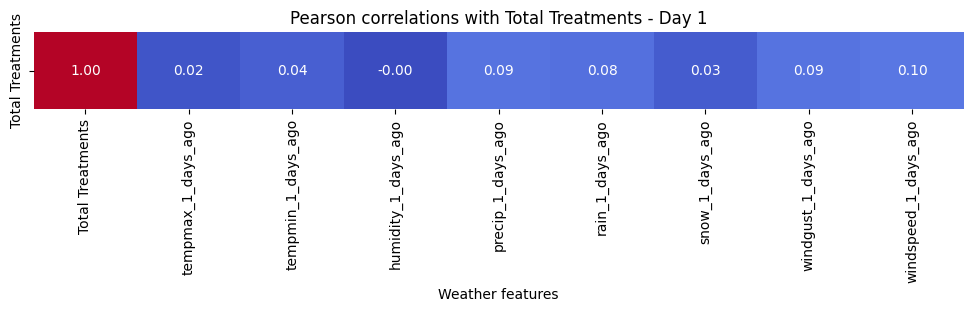

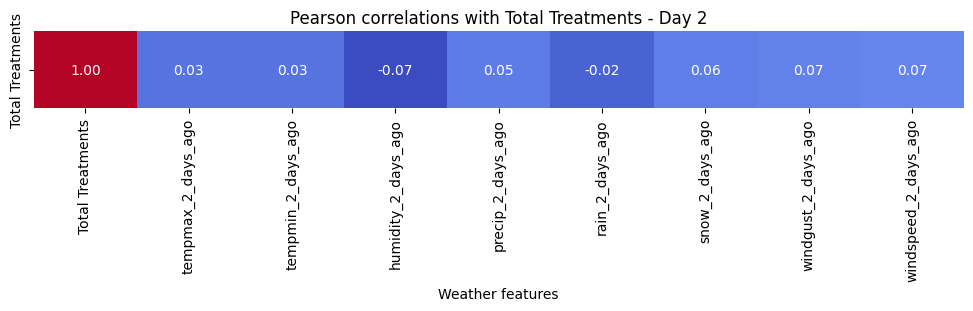

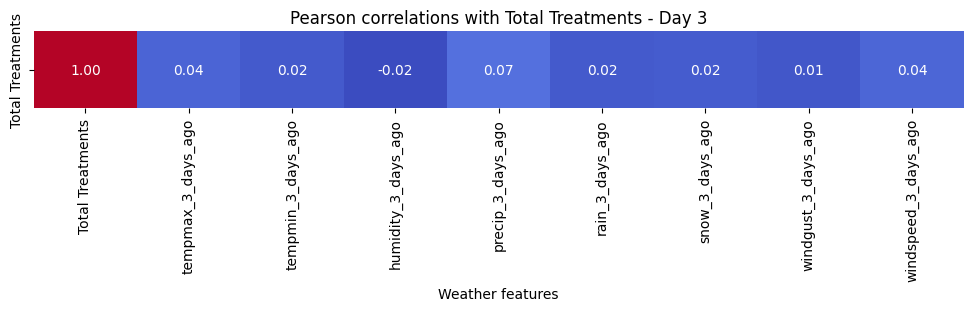

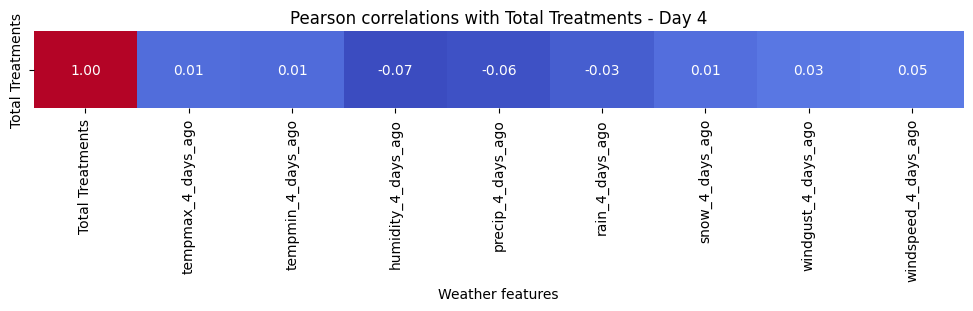

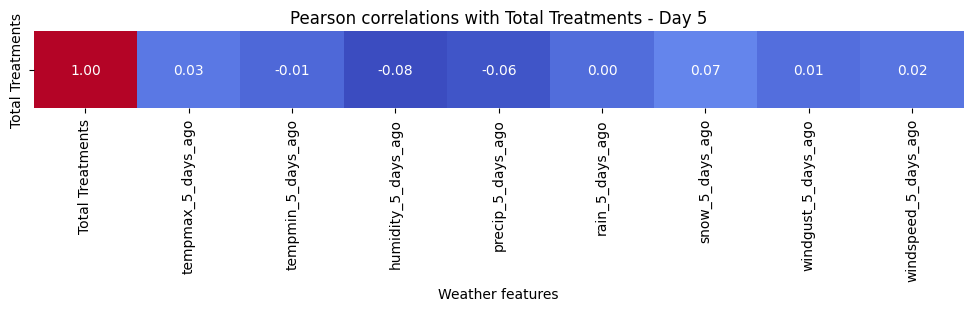

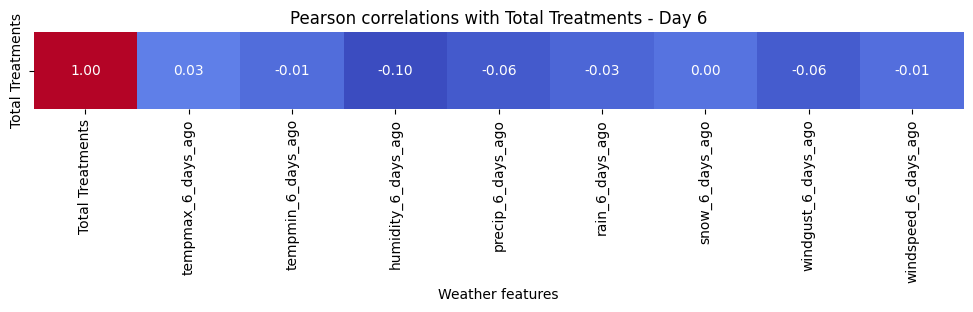

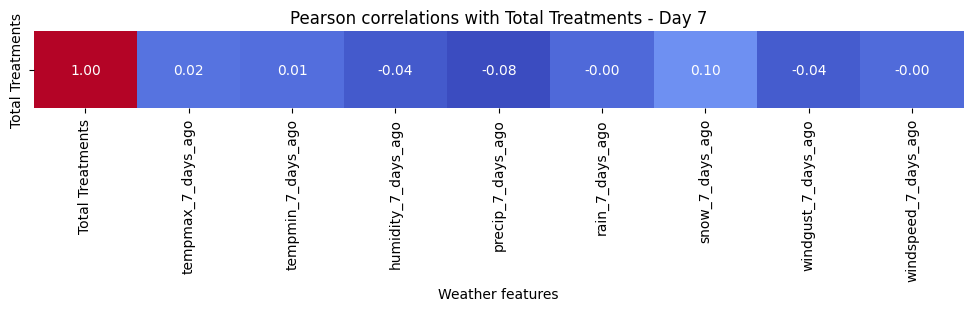

In [66]:
for day, correlations in pearson_correlations.items():
    corr_df = correlations.to_frame().rename(columns={'Total Treatments': 'Correlation'}).dropna()
    
    corr_df = corr_df.T
    
    plt.figure(figsize=(12, 1))
    sns.heatmap(corr_df, annot=True, fmt=".2f", cmap='coolwarm', cbar=False, 
                xticklabels=corr_df.columns, yticklabels=['Total Treatments'])
    
    plt.title(f'Pearson correlations with Total Treatments - {day}')
    plt.xlabel('Weather features')
    plt.show()

In [67]:
features = treatment_counts_with_weather.drop(columns=['Total Treatments', 'Date']).columns
target = "Total Treatments"

X = treatment_counts_with_weather[features]
y = treatment_counts_with_weather[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("There are in total", len(X), "observations, of which", len(X_train), "are in the train set, and", len(X_test), "in the test set.")

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)

accuracy = svr_model.score(X_test_scaled, y_test)
print(f"Model R^2: {accuracy:.2f}")

y_pred = svr_model.predict(X_test_scaled)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

There are in total 398 observations, of which 318 are in the train set, and 80 in the test set.
Model R^2: -0.17
Root Mean Squared Error (RMSE): 4.59
Mean Absolute Error (MAE): 2.87


In [68]:
features = treatment_counts_with_weather.drop(columns=['Total Treatments', 'Date']).columns
target = "Total Treatments"

X = treatment_counts_with_weather[features]
y = treatment_counts_with_weather[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"There are in total {len(X)} observations, of which {len(X_train)} are in the train set, and {len(X_test)} in the test set.")

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

param_grid = {
    'C': [0.1, 1, 2, 5, 10],
    'kernel': ['linear', 'poly', 'rbf'],
    'gamma': ['scale', 'auto'],
    'epsilon': [0.1, 0.2, 0.5]
}

svr_model = SVR()

grid_search = GridSearchCV(svr_model, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

best_model_svr = grid_search.best_estimator_

accuracy_svr_best = best_model_svr.score(X_test_scaled, y_test)
print(f"SVR Model (after tuning) R^2: {accuracy_svr_best:.2f}")

y_pred_svr_best = best_model_svr.predict(X_test_scaled)

rmse_svr_best = root_mean_squared_error(y_test, y_pred_svr_best)
mae_svr_best = mean_absolute_error(y_test, y_pred_svr_best)

print(f"Root Mean Squared Error (RMSE): {rmse_svr_best:.2f}")
print(f"Mean Absolute Error (MAE): {mae_svr_best:.2f}")

cross_val_scores_svr_best = cross_val_score(best_model_svr, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-Validation R^2 scores (after tuning): {cross_val_scores_svr_best}")
print(f"Mean Cross-Validation R^2 (after tuning): {cross_val_scores_svr_best.mean():.2f}")

There are in total 398 observations, of which 318 are in the train set, and 80 in the test set.
Best parameters: {'C': 5, 'epsilon': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
SVR Model (after tuning) R^2: -0.07
Root Mean Squared Error (RMSE): 4.38
Mean Absolute Error (MAE): 2.90
Cross-Validation R^2 scores (after tuning): [-0.0315222  -0.0707053  -0.1047796  -0.13404222 -0.10176772]
Mean Cross-Validation R^2 (after tuning): -0.09
